# Cataract Classification Project
#### A deep learning project for classifying cataract images as "mature" or "immature" using TensorFlow/Keras.

## Project Overview

This project implements a convolutional neural network (CNN) to automatically classify cataract images into two categories:
- **Mature** cataracts
- **Immature** cataracts

The model is trained on a dataset of 410 eye images and achieves high accuracy in distinguishing between these two cataract types.

In [1]:
import tensorflow as tf
tf.keras.backend.clear_session()

2025-10-22 20:30:38.306765: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-22 20:30:38.538952: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-22 20:30:40.697123: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Dataset

- **Total images**: 410
- **Classes**: 2 (mature, immature)
- **Training set**: 328 images (80% split)
- **Validation set**: 82 images (20% split)
- **Image dimensions**: 416 × 416 pixels

In [2]:
url = 'cataract'

In [3]:
import pathlib

In [4]:
data_dir=pathlib.Path(url)

## Model Architecture

The project explores two different neural network architectures:

In [5]:
import tensorflow as tf

In [6]:
batch_size = 16
height = 416
width = 416

In [7]:
train = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=171,
    image_size=(height,width),
    batch_size=batch_size
)

Found 410 files belonging to 2 classes.
Using 328 files for training.


I0000 00:00:1761175844.082168   92309 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
validation = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=171,
    image_size=(height,width),
    batch_size=batch_size
)

Found 410 files belonging to 2 classes.
Using 82 files for validation.


In [9]:
train.class_names

['immature', 'mature']

In [10]:
tf.random.set_seed(245)

### 1. Simple Dense Network
- Input layer (416×416×3)
- Rescaling layer (normalization)
- Flatten layer
- Dense layer (64 units, ReLU activation)
- Output layer (1 unit, sigmoid activation)

In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(416, 416, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  #
])


In [12]:
# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [13]:
epoch =10

history = model.fit(
    train,
    validation_data=validation,
    epochs=epoch,
    batch_size=batch_size
)

Epoch 1/10


2025-10-22 20:30:46.273812: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f9614008930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-22 20:30:46.273860: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-22 20:30:46.312060: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-22 20:30:46.469493: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


 7/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5158 - loss: 72.4981

I0000 00:00:1761175847.473725   92458 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 434ms/step - accuracy: 0.5945 - loss: 41.8274 - val_accuracy: 0.6829 - val_loss: 15.7174
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ -6s -310428us/step - accuracy: 0.8567 - loss: 4.9965 - val_accuracy: 0.7683 - val_loss: 5.4084
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8628 - loss: 2.5325 - val_accuracy: 0.8659 - val_loss: 1.7459
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9512 - loss: 0.5989 - val_accuracy: 0.9146 - val_loss: 2.1469
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9787 - loss: 0.1682 - val_accuracy: 0.9268 - val_loss: 1.2900
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9817 - loss: 0.0596 - val_accuracy: 0.9268 - val_loss: 1.9791
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9909 - loss: 0.0816 - val_accuracy: 0.9268 - val_loss: 1.0296
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9970 - loss: 0.0038 - val_accuracy: 0.9268 - va

In [14]:
import matplotlib.pyplot as plt

In [15]:
def plot_results(history,epoch):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  range_epoch = range(epoch)
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.plot(range_epoch, acc, label='Train Accuracy')
  plt.plot(range_epoch, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')


  plt.subplot(1, 2, 2)
  plt.plot(range_epoch, loss, label='Train Loss')
  plt.plot(range_epoch, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.show()

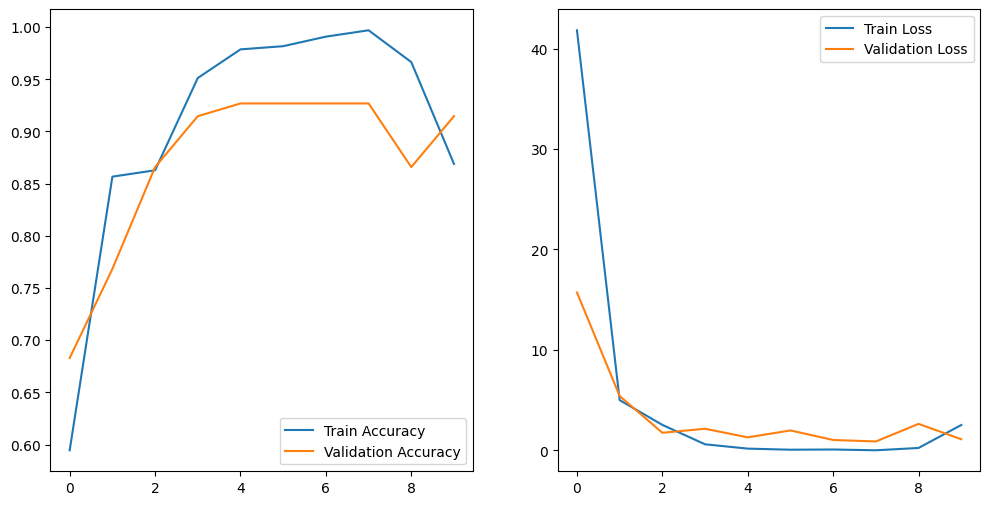

In [16]:
plot_results(history,epoch)

### 2. Convolutional Neural Network
- Input layer (416×416×3)
- Rescaling layer (normalization)
- Conv2D layer (16 filters, 3×3 kernel, ReLU activation)
- MaxPooling2D layer (2×2)
- Conv2D layer (16 filters, 3×3 kernel, ReLU activation)
- MaxPooling2D layer (2×2)
- Flatten layer
- Dense layer (64 units, ReLU activation)
- Output layer (1 unit, sigmoid activation)

In [17]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(416, 416, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


## Training Configuration

- **Batch size**: 16
- **Epochs**: 10
- **Optimizer**: Adam
- **Loss function**: Binary crossentropy
- **Metrics**: Accuracy

In [18]:
# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [19]:
epoch =10

history = model.fit(
    train,
    validation_data=validation,
    epochs=epoch,
    batch_size=batch_size
)

Epoch 1/10


2025-10-22 20:31:06.156050: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng17{k25=2} for conv (f32[16,16,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,16,207,207]{3,2,1,0}, f32[16,16,205,205]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-22 20:31:06.180134: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 6.364691457s
Trying algorithm eng17{k25=2} for conv (f32[16,16,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,16,207,207]{3,2,1,0}, f32[16,16,205,205]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0

21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 346ms/step - accuracy: 0.5274 - loss: 1.4469 - val_accuracy: 0.6951 - val_loss: 0.6301
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7805 - loss: 0.5233 - val_accuracy: 0.8171 - val_loss: 0.4622
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 366ms/step - accuracy: 0.9177 - loss: 0.2793 - val_accuracy: 0.8902 - val_loss: 0.2605
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9848 - loss: 0.0965 - val_accuracy: 0.9024 - val_loss: 0.1729
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9939 - loss: 0.0324 - val_accuracy: 0.9878 - val_loss: 0.0735
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 0.9512 - val_loss: 0.1033
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 0.9634 - val_loss: 0.0758
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9878 - val_loss:

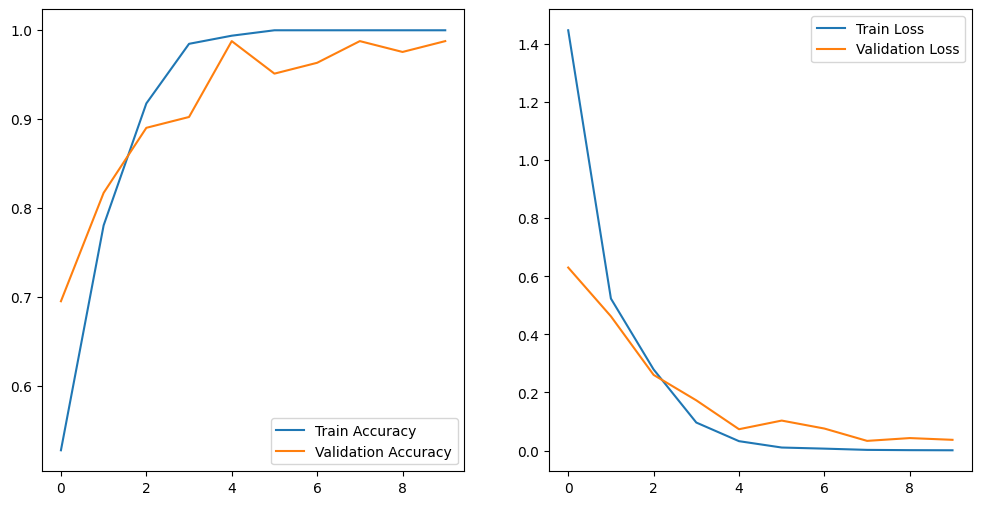

In [20]:
plot_results(history,epoch)

## Results

The CNN model demonstrated superior performance with:
- Training accuracy approaching 100%
- Validation accuracy reaching 92.68%
- Smooth convergence with minimal overfitting

In [21]:
input_shape=(416, 416, 3)

In [22]:
model_base = tf.keras.applications.InceptionV3(input_shape=input_shape,include_top=False,weights='imagenet' )

In [23]:
model_base.trainable = False

In [24]:
model_base.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 416, 416,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 207, 207,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 207, 207,  │         96 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 207, 207,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 205, 205,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 205, 205,  │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 205, 205,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 205, 205,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 205, 205,  │        192 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 205, 205,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 102, 102,  │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 102, 102,  │      5,120 │ max_pooling2d_2[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 102, 102,  │        240 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 102, 102,  │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 100, 100,  │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        576 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 100, 100,  │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [25]:
rescale = tf.keras.layers.Rescaling((1./255))
train = train.map(lambda x, y: (rescale(x), y))
validation = validation.map(lambda x, y: (rescale(x), y))

In [26]:
last_layer = model_base.get_layer('mixed7')

last_output = last_layer.output

In [27]:
x = tf.keras.layers.GlobalMaxPooling2D()(last_output)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=model_base.input, outputs=x)

In [28]:
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'binary_crossentropy',
              metrics=['accuracy'])

In [29]:
epoch =10

history = model.fit(
    train,
    validation_data=validation,
    epochs=epoch,
    batch_size=batch_size

)

Epoch 1/10


2025-10-22 20:31:34.152536: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 790.04MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-22 20:31:35.412293: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-22 20:31:37.413983: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.08GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


 4/21 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.5768 - loss: 0.8240

2025-10-22 20:31:43.797716: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.15GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-22 20:31:51.210660: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng34{k2=1,k4=0,k5=1,k6=0,k7=0,k19=0} for conv (f32[8,192,100,100]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,80,102,102]{3,2,1,0}, f32[192,80,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-22 20:31:51.211964: E external/local_xla/xla/service/slow_oper

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5955 - loss: 0.8225

2025-10-22 20:31:57.498808: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-22 20:31:57.922714: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.94GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-22 20:32:06.243591: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[2,96,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[2,96,49,49]{3,2,1,0}, f32[96,96,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_

21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5854 - loss: 0.8251 - val_accuracy: 0.5000 - val_loss: 0.7776
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.7073 - loss: 0.5694 - val_accuracy: 0.7927 - val_loss: 0.4963
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.8079 - loss: 0.4391 - val_accuracy: 0.6951 - val_loss: 0.5280
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.7957 - loss: 0.4298 - val_accuracy: 0.8415 - val_loss: 0.3841
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.9085 - loss: 0.3023 - val_accuracy: 0.8415 - val_loss: 0.3334
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ -4s -219946us/step - accuracy: 0.9238 - loss: 0.2617 - val_accuracy: 0.9390 - val_loss: 0.2786
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.9390 - loss: 0.2290 - val_accuracy: 0.8659 - val_loss: 0.2765
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.9695 - loss: 0.1772 - val_accuracy: 0.9024 - v

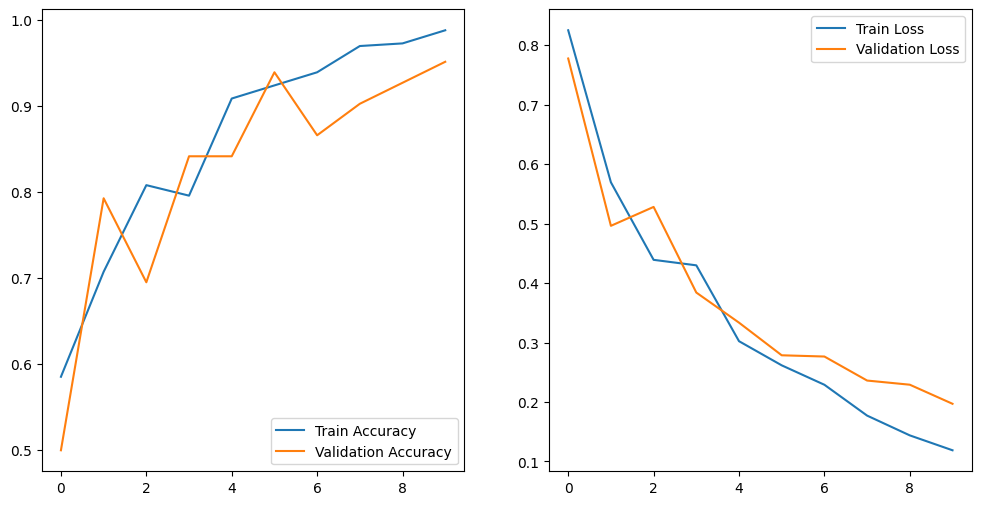

In [30]:
plot_results(history,epoch)

## Project Structure

The notebook is organized into three main sections:

1. **Data Preparation** - Loading and preprocessing the cataract image dataset
2. **Simple Model Implementation** - Baseline model with dense layers
3. **CNN Implementation** - Advanced model with convolutional layers for improved feature extraction

In [31]:
import numpy as np

# Generating predictions on the validation data
prediction = model.predict(validation)

# Converting predictions to binary classes (0 or 1)
prediction_binary = (prediction > 0.5).astype(int).flatten()

# Collect all true labels at once
full_true_labels = np.concatenate([y for x, y in validation])

print("=== PREDICTIONS vs TRUE LABELS COMPARISON (First 5 samples) ===")


for i in range(5):
    prediction = prediction_binary[i]
    true_label = full_true_labels[i]
    correct = "✓" if prediction == true_label else "✗"

    print(f"Image {i+1}: Prediction: {prediction}, True label: {true_label} {correct}")

# Calculate accuracy on the first 5 samples
correct_5 = sum(prediction_binary[:5] == full_true_labels[:5])
print(f"\nAccuracy on the 5 samples: {correct_5/5*100:.1f}%")

# Overall accuracy on the validation set
overall_accuracy = np.mean(prediction_binary == full_true_labels)
print(f"Overall accuracy on the validation set: {overall_accuracy*100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 758ms/step
=== PREDICTIONS vs TRUE LABELS COMPARISON (First 5 samples) ===
Image 1: Prediction: 0, True label: 0 ✓
Image 2: Prediction: 1, True label: 0 ✗
Image 3: Prediction: 0, True label: 1 ✗
Image 4: Prediction: 0, True label: 0 ✓
Image 5: Prediction: 0, True label: 1 ✗

Accuracy on the 5 samples: 40.0%
Overall accuracy on the validation set: 43.90%


2025-10-22 20:32:34.291758: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [32]:
len(list(validation))

2025-10-22 20:32:34.399659: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


6

In [33]:
# Initialize the TFLite converter from the trained Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Optional but recommended for apps) Add optimizations FP16 (float16) quantization reduces the model size by half and speeds up inference on mobile device GPUs, with minimal loss of accuracy.
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Convert the model
flite_model = converter.convert()

# Save the TFLite model to a file
with open('cataract_model_fp16.tflite', 'wb') as f:
    f.write(flite_model)

print("✅ TFLite model (FP16) saved as 'cataract_model_fp16.tflite'")

INFO:tensorflow:Assets written to: /tmp/tmpukmbq9wm/assets


INFO:tensorflow:Assets written to: /tmp/tmpukmbq9wm/assets


Saved artifact at '/tmp/tmpukmbq9wm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 416, 416, 3), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140285578333840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578335760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578333456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578334992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578335568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578336528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578331728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578334800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578336720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140285578337488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028557833

W0000 00:00:1761175960.736256   92309 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1761175960.736306   92309 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-22 20:32:40.736928: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpukmbq9wm
2025-10-22 20:32:40.749800: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-22 20:32:40.749835: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpukmbq9wm
I0000 00:00:1761175960.867568   92309 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-10-22 20:32:40.888779: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-22 20:32:41.591867: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpukmbq9wm
2025-10-22 20:32:41.756637: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

✅ TFLite model (FP16) saved as 'cataract_model_fp16.tflite'
